#### DSCI 6650: Reinforcement Learning Master of Data Science (MDSc)
#### Assignment 2: Reinforcement Learning

#### Name: Hashna Binte Nahar
#### ID:202290355

### Part1:
### Bellman equation:
###### 1) We want to solve:
#### V=(I−ɣ Pπ)-1Rπ
###### V: value function vector (length 25 for 5×5 grid) •	Builds transition matrix Pπ: state transition matrix under uniform policy (25×25) •	Builds reward vector Rπ: expected reward vector under uniform policy (length 25) •	ɣ =0.95
###### Displays the resulting value function as a heatmap.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


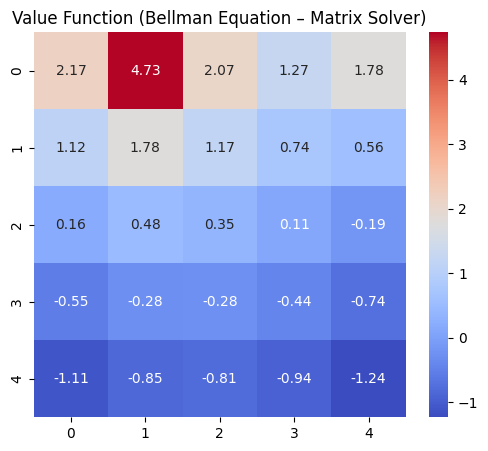

In [2]:
# Grid parameters
GRID_SIZE = 5
NUM_STATES = GRID_SIZE * GRID_SIZE
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right
GAMMA = 0.95

# Special squares
BLUE = (0, 1)
GREEN = (0, 4)
RED = (3, 2)
YELLOW = (4, 4)

# Helper function: convert (i, j) to state index
def to_index(i, j):
    return i * GRID_SIZE + j

# Initialize transition matrix and reward vector
P_pi = np.zeros((NUM_STATES, NUM_STATES))  # Transition matrix
R_pi = np.zeros(NUM_STATES)                # Reward vector

# Construct P_pi and R_pi under uniform random policy
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        s = to_index(i, j)

        for action in ACTIONS:
            ni, nj = i + action[0], j + action[1]
            next_i, next_j = i, j
            reward = 0

            # Identify if square is white or yellow (i.e., not a special square)
            is_white_or_yellow = (i, j) not in [BLUE, GREEN, RED]

            # ==========================================
            # CASE 1: Off-grid move from white/yellow
            # Reward = -0.5, stay in place
            # ==========================================
            if not (0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE) and is_white_or_yellow:
                reward = -0.5
                next_i, next_j = i, j

            # ==========================================
            # CASE 2: Special BLUE square
            # Reward = +5, teleport to RED
            # ==========================================
            elif (i, j) == BLUE:
                reward = 5
                next_i, next_j = RED

            # ==========================================
            # CASE 3: Special GREEN square
            # Reward = +2.5, teleport randomly to RED or YELLOW
            # ==========================================
            elif (i, j) == GREEN:
                reward = 2.5
                red_idx = to_index(*RED)
                yellow_idx = to_index(*YELLOW)
                P_pi[s, red_idx] += 0.25 * 0.5
                P_pi[s, yellow_idx] += 0.25 * 0.5
                R_pi[s] += 0.25 * reward
                continue  # Skip the rest of this action loop

            # ==========================================
            # CASE 4: Normal move from white/red/yellow
            # Reward = 0, go to next cell
            # ==========================================
            else:
                next_i, next_j = ni, nj
                reward = 0

            # Finalize next state and update matrices
            s_prime = to_index(next_i, next_j)
            P_pi[s, s_prime] += 0.25
            R_pi[s] += 0.25 * reward

# ================================
# Solve Bellman equation:
# V = (I - γ * Pπ)^(-1) * Rπ
# ================================
I = np.eye(NUM_STATES)
A = I - GAMMA * P_pi
V = np.linalg.solve(A, R_pi)  # Solve linear system

# Reshape for visualization
V_grid = V.reshape((GRID_SIZE, GRID_SIZE))

# Plot value function heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(V_grid, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Value Function (Bellman Equation – Matrix Solver)")
plt.show()


### Iterative Policy Evaluation

#### Iterative Policy Evaluation
##### Estimate V^π using:
##### V_{k+1}(s) = R(s) + γ * Σ_{s'} P(s' | s, π) * V_k(s')
##### Iteratively update until convergence (|V_{k+1} - V_k| < θ)

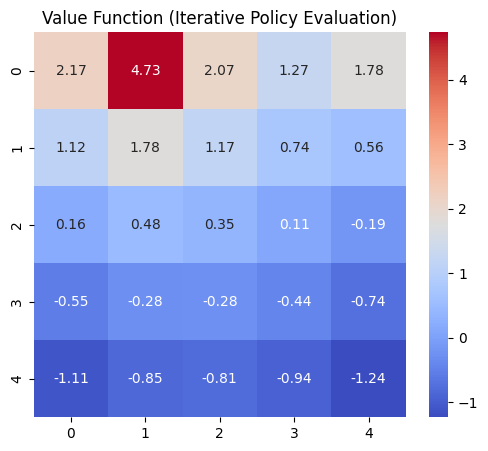

In [3]:
# =============================
# Iterative Policy Evaluation
# =============================
def iterative_policy_evaluation(P_pi, R_pi, gamma=0.95, theta=1e-6, max_iter=1000):
    V = np.zeros(P_pi.shape[0])  # Number of states
    for _ in range(max_iter):
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(len(V)):
            V_new[s] = R_pi[s] + gamma * np.dot(P_pi[s], V)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        if delta < theta:
            break
    return V.reshape((GRID_SIZE, GRID_SIZE))

# Run the evaluation
V_iter = iterative_policy_evaluation(P_pi, R_pi, GAMMA)

# Plot the value function
plt.figure(figsize=(6, 5))
sns.heatmap(V_iter, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Value Function (Iterative Policy Evaluation)")
plt.show()


### Compare Results of Iterative vs Analytical Solutions
###### We already computed: 1. Analytical Value Function using the Bellman equations (linear system) 2.Iterative Policy Evaluation using repeated updates. Let’s now compare them side by side numerically and visually.

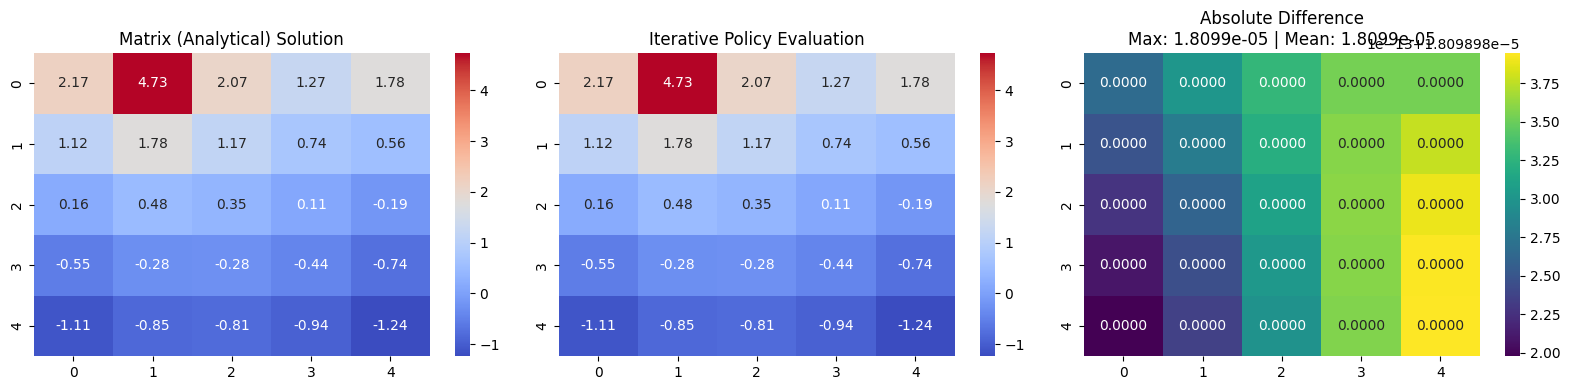

In [4]:
# Solve using matrix (analytical) solution
I = np.eye(NUM_STATES)
A = I - GAMMA * P_pi
V_matrix = np.linalg.solve(A, R_pi).reshape((GRID_SIZE, GRID_SIZE))

# Solve using iterative method (already done or reuse function)
V_iter = iterative_policy_evaluation(P_pi, R_pi, GAMMA)

# Compare values
diff = np.abs(V_matrix - V_iter)
max_diff = np.max(diff)
mean_diff = np.mean(diff)

# Display both heatmaps
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
sns.heatmap(V_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrix (Analytical) Solution")

plt.subplot(1, 3, 2)
sns.heatmap(V_iter, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Iterative Policy Evaluation")

plt.subplot(1, 3, 3)
sns.heatmap(diff, annot=True, fmt=".4f", cmap="viridis")
plt.title(f"Absolute Difference\nMax: {max_diff:.4e} | Mean: {mean_diff:.4e}")

plt.tight_layout()
plt.show()


###### Both value functions should look nearly identical. The difference heatmap should show very small values. Showing that iterative evaluation has converged properly.This verifies correctness and equivalence of both methods under the same policy.



### Part 1 (2):
###### Determine the optimal policy for the gridworld problem by (1) explicitly solving the Bellman optimality equation (2) using policy iteration with iterative policy evaluation (3) policy improvement with value iteration.

In [13]:
# Build P[s,a,s'] and R[s,a] for optimality algorithms
P = np.zeros((NUM_STATES, len(ACTIONS), NUM_STATES))
R = np.zeros((NUM_STATES, len(ACTIONS)))

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        s = to_index(i, j)
        for a_idx, action in enumerate(ACTIONS):
            ni, nj = i + action[0], j + action[1]
            next_i, next_j = i, j
            reward = 0

            is_white_or_yellow = (i, j) not in [BLUE, GREEN, RED]

            # Off-grid from white/yellow
            if not (0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE) and is_white_or_yellow:
                reward = -0.5
                next_i, next_j = i, j

            # BLUE: +5 reward, teleport to RED
            elif (i, j) == BLUE:
                reward = 5
                next_i, next_j = RED

            # GREEN: +2.5 reward, teleport 50/50 to RED or YELLOW
            elif (i, j) == GREEN:
                reward = 2.5
                red_idx = to_index(*RED)
                yellow_idx = to_index(*YELLOW)
                P[s, a_idx, red_idx] += 0.5
                P[s, a_idx, yellow_idx] += 0.5
                R[s, a_idx] = reward
                continue  # Skip the rest

            # Normal move (including red/yellow origin)
            else:
                if 0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE:
                    next_i, next_j = ni, nj
                # reward stays 0

            s_prime = to_index(next_i, next_j)
            P[s, a_idx, s_prime] = 1.0
            R[s, a_idx] = reward

# Greedy policy extraction
def extract_greedy_policy(V, P, R, gamma=0.95):
    policy = np.zeros(NUM_STATES, dtype=int)
    for s in range(NUM_STATES):
        q_vals = []
        for a in range(len(ACTIONS)):
            q_sa = np.sum(P[s, a] * (R[s, a] + gamma * V))
            q_vals.append(q_sa)
        policy[s] = np.argmax(q_vals)
    return policy



In [14]:
# 1) Bellman Optimality (Value Iteration to Convergence)
def bellman_optimality_value_iteration(P, R, gamma=0.95, theta=1e-5):
    V = np.zeros(NUM_STATES)
    while True:
        delta = 0
        for s in range(NUM_STATES):
            v = V[s]
            q_vals = [np.sum(P[s, a] * (R[s, a] + gamma * V)) for a in range(len(ACTIONS))]
            V[s] = max(q_vals)
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break
    policy = extract_greedy_policy(V, P, R, gamma)
    return V, policy


In [15]:
# 2) Policy Iteration
def policy_iteration(P, R, gamma=0.95, theta=1e-5):
    policy = np.zeros(NUM_STATES, dtype=int)
    V = np.zeros(NUM_STATES)
    stable = False
    while not stable:
        # Policy Evaluation
        while True:
            delta = 0
            for s in range(NUM_STATES):
                a = policy[s]
                v = V[s]
                V[s] = np.sum(P[s, a] * (R[s, a] + gamma * V))
                delta = max(delta, abs(v - V[s]))
            if delta < theta:
                break
        # Policy Improvement
        stable = True
        for s in range(NUM_STATES):
            old_a = policy[s]
            q_vals = [np.sum(P[s, a] * (R[s, a] + gamma * V)) for a in range(len(ACTIONS))]
            policy[s] = np.argmax(q_vals)
            if policy[s] != old_a:
                stable = False
    return V, policy


In [16]:
# 3) Value Iteration (same as Bellman Optimality but separated)
def value_iteration(P, R, gamma=0.95, theta=1e-5):
    V = np.zeros(NUM_STATES)
    while True:
        delta = 0
        for s in range(NUM_STATES):
            v = V[s]
            q_vals = [np.sum(P[s, a] * (R[s, a] + gamma * V)) for a in range(len(ACTIONS))]
            V[s] = max(q_vals)
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break
    policy = extract_greedy_policy(V, P, R, gamma)
    return V, policy



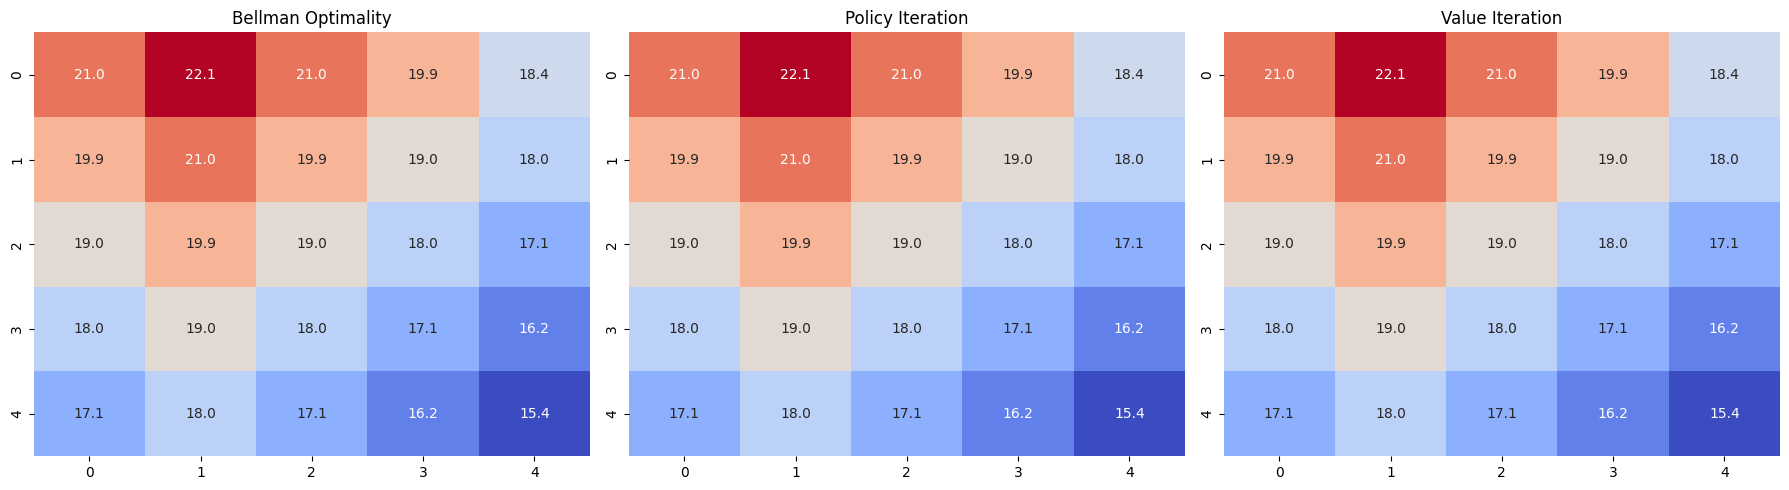

In [17]:
# Run all three methods
V_bellman, pi_bellman = bellman_optimality_value_iteration(P, R)
V_pi, pi_pi = policy_iteration(P, R)
V_vi, pi_vi = value_iteration(P, R)

# Plot value heatmaps
def plot_values(V_list, titles):
    plt.figure(figsize=(18, 5))
    for idx, (V, title) in enumerate(zip(V_list, titles), 1):
        plt.subplot(1, 3, idx)
        grid = V.reshape(GRID_SIZE, GRID_SIZE)
        sns.heatmap(grid, annot=True, fmt=".1f", cmap="coolwarm", cbar=False)
        plt.title(title)
    plt.tight_layout()
    plt.show()

plot_values([V_bellman, V_pi, V_vi],
            ["Bellman Optimality", "Policy Iteration", "Value Iteration"])

# Plot policy arrows
def plot_policies(policies, titles):
    plt.figure(figsize=(18, 5))
    for idx, (policy, title) in enumerate(zip(policies, titles), 1):
        plt.subplot(1, 3, idx)
        grid = np.array([ACTION_NAMES[a] for a in policy]).reshape(GRID_SIZE, GRID_SIZE)
        for i in range(GRID_SIZE):
            for j in range(GRID_SIZE):
                plt.text(j + 0.5, i + 0.5, grid[i, j], ha='center', va='center', fontsize=14)
        for (i, j), label in {BLUE: 'B', GREEN: 'G', RED: 'R', YELLOW: 'Y'}.items():
            plt.text(j + 0.5, i + 0.8, label, ha='center', color='blue', fontsize=10)
        plt.xlim(0, GRID_SIZE)
        plt.ylim(0, GRID_SIZE)
        plt.title(title)
        plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

#### Clarification on Optimal Policy Methods*

##### In Question 1of Part 2, we were asked to determine the optimal policy using three different approaches. While the wording might suggest all three rely on explicitly solving the Bellman optimality equation, the intended interpretation corresponds to three distinct standard methods for computing optimal policies in reinforcement learning:

##### Value Iteration: This method approximates the solution to the Bellman optimality equation by iteratively applying the Bellman update with a max over actions. It yields the optimal value function and the corresponding greedy policy.

##### Policy Iteration: This involves alternating between iterative policy evaluation (computing the value function for a fixed policy) and policy improvement (updating the policy greedily based on the current value function). This method is conceptually separate from solving the Bellman optimality equation directly.

##### Policy Improvement via Value Iteration: This refers again to Value Iteration, where both evaluation and improvement are combined into a single update step. This method incrementally improves the policy through greedy updates on the value function.

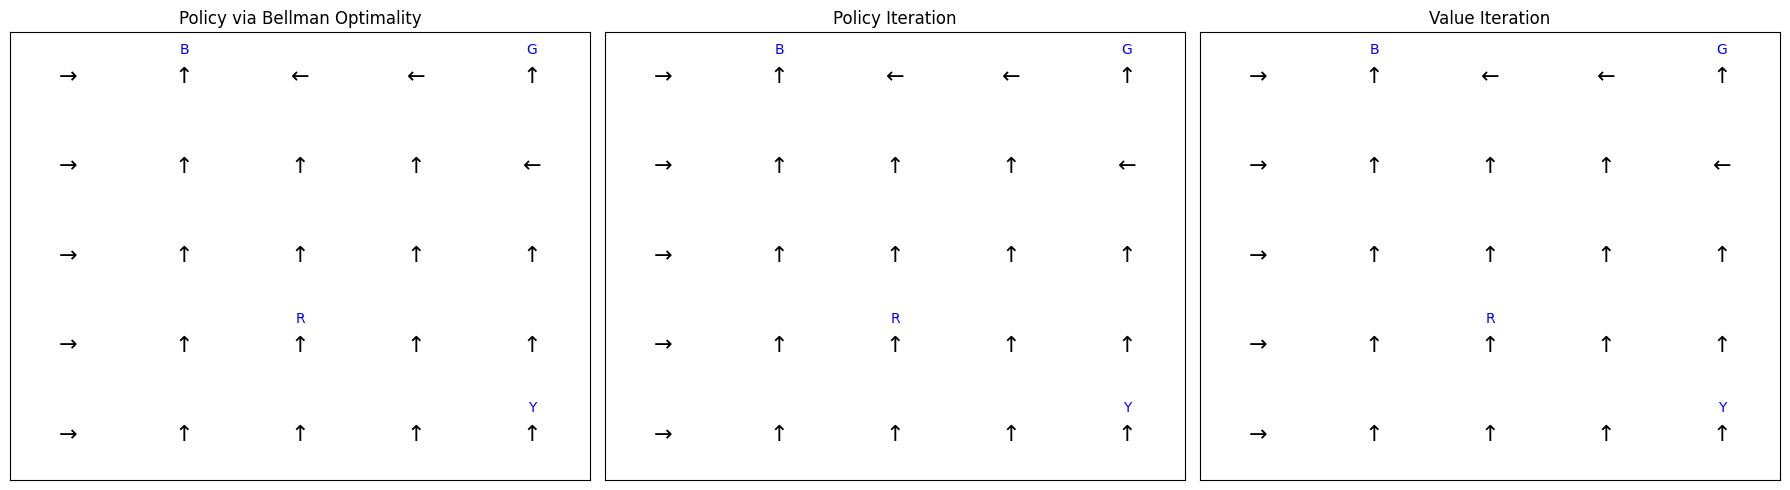

In [19]:
#Arrow-only visualization:
# Add this near the top of your script
ACTION_NAMES = ['↑', '↓', '←', '→']  # Up, Down, Left, Right

def plot_policy_arrows_only(policies, titles):
    plt.figure(figsize=(18, 5))
    for idx, (policy, title) in enumerate(zip(policies, titles), 1):
        plt.subplot(1, 3, idx)
        grid_pi = np.array([ACTION_NAMES[a] for a in policy]).reshape(GRID_SIZE, GRID_SIZE)

        # Draw arrows only
        for i in range(GRID_SIZE):
            for j in range(GRID_SIZE):
                plt.text(j + 0.5, i + 0.5, grid_pi[i, j],
                         ha='center', va='center', fontsize=16, color='black')

        # Mark special states
        for (i, j), label in {BLUE: 'B', GREEN: 'G', RED: 'R', YELLOW: 'Y'}.items():
            plt.text(j + 0.5, i + 0.2, label,
                     ha='center', va='center', fontsize=10, color='blue')

        plt.title(title)
        plt.xlim(0, GRID_SIZE)
        plt.ylim(0, GRID_SIZE)
        plt.gca().invert_yaxis()
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()

# Generate the arrow-only visualization
plot_policy_arrows_only(
    [pi_bellman, pi_pi, pi_vi],
    ["Policy via Bellman Optimality", "Policy Iteration", "Value Iteration"]
)


### Part 2 Final

##### Use the Monte Carlo method with (1) exploring starts and (2) without exploring starts but the ϵ-soft approach to learn an optimal policy for this modified gridworld problem. Use the same discount factor of γ = 0.95 as you have in the Part 1 above. You can start with a policy with equiprobable moves.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ---------------- Environment Setup ----------------
GRID_SIZE = 5
NUM_STATES = GRID_SIZE * GRID_SIZE
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # Up, Down, Left, Right
ACTION_NAMES = ['↑', '↓', '←', '→']
GAMMA = 0.95
EPSILON = 0.1
MAX_STEPS = 500  # to avoid infinite loops

# Special and terminal states
BLUE = (0, 1)
GREEN = (0, 4)
RED = (4, 2)
YELLOW = (4, 4)
TERMINAL_STATES = [(2, 0), (2, 4), (4, 0)]

def to_index(i, j): return i * GRID_SIZE + j
def to_coords(s): return divmod(s, GRID_SIZE)

# ---------------- Step Function ----------------
def step(state, action):
    if to_coords(state) in TERMINAL_STATES:
        return state, 0, True  # terminal

    i, j = to_coords(state)
    ni, nj = i + action[0], j + action[1]
    reward, done = 0, False

    # BLUE teleport
    if (i, j) == BLUE:
        return to_index(*RED), 5, False

    # GREEN teleport (50% RED, 50% YELLOW)
    if (i, j) == GREEN:
        target = RED if np.random.rand() < 0.5 else YELLOW
        return to_index(*target), 2.5, False

    # Off-grid from white/red/yellow → -0.5 (stay put)
    if not (0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE) and (i, j) not in [BLUE, GREEN]:
        return state, -0.5, False

    # Normal moves (white/red/yellow) → -0.2
    if 0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE:
        next_state = to_index(ni, nj)
        reward = -0.2
        done = (ni, nj) in TERMINAL_STATES
        return next_state, reward, done

    return state, reward, done

# ---------------- Episode Generator ----------------
def generate_episode(policy=None, exploring_starts=False):
    states, actions, rewards = [], [], []
    # Start in random non-terminal state
    while True:
        s = random.randint(0, NUM_STATES-1)
        if to_coords(s) not in TERMINAL_STATES:
            break
    # Random start action for ES, else follow policy or random
    a = random.choice(range(len(ACTIONS))) if exploring_starts else (
        policy[s] if policy is not None else random.choice(range(len(ACTIONS)))
    )

    done, step_count = False, 0
    while not done and step_count < MAX_STEPS:
        states.append(s)
        actions.append(a)
        s_next, r, done = step(s, ACTIONS[a])
        rewards.append(r)
        if not done:
            a = policy[s_next] if policy is not None else random.choice(range(len(ACTIONS)))
        s = s_next
        step_count += 1
    return states, actions, rewards
    

####   Monte Carlo Control (Exploring Starts)

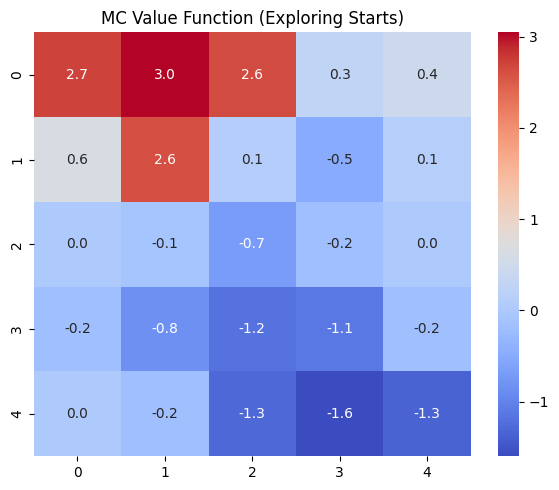

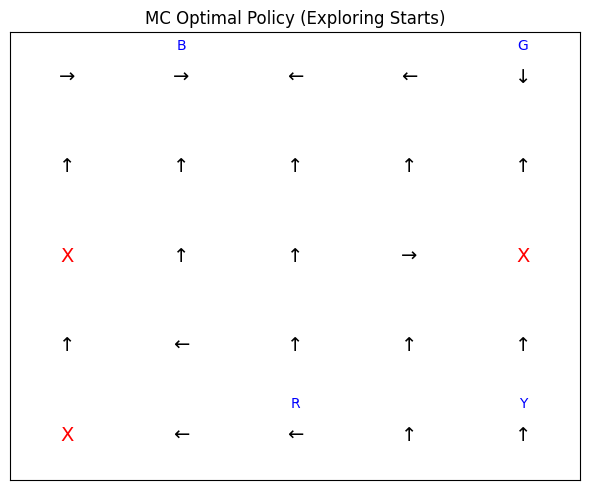

In [26]:
# ---------------- Monte Carlo Control (Exploring Starts) ----------------
def mc_control_exploring_starts(num_episodes=10000):
    Q = np.zeros((NUM_STATES, len(ACTIONS)))
    returns_count = np.zeros((NUM_STATES, len(ACTIONS)))
    policy = np.zeros(NUM_STATES, dtype=int)

    for _ in range(num_episodes):
        states, actions, rewards = generate_episode(exploring_starts=True)
        G, visited = 0, set()
        for t in reversed(range(len(states))):
            G = GAMMA * G + rewards[t]
            s, a = states[t], actions[t]
            if (s, a) not in visited:
                visited.add((s, a))
                returns_count[s, a] += 1
                Q[s, a] += (G - Q[s, a]) / returns_count[s, a]
                policy[s] = np.argmax(Q[s])
    return Q, policy
#### Monte Carlo with Exploring Starts visualization
# ---------------- Monte Carlo Control with Exploring Starts ----------------
Q_es, pi_es = mc_control_exploring_starts()

V_es = np.max(Q_es, axis=1).reshape(GRID_SIZE, GRID_SIZE)

# Value Heatmap (Exploring Starts)
plt.figure(figsize=(6, 5))
sns.heatmap(V_es, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("MC Value Function (Exploring Starts)")
plt.tight_layout()
plt.show()

# Policy Arrows (Exploring Starts) - X marks terminal states
plt.figure(figsize=(6, 5))
grid_pi = np.array([ACTION_NAMES[a] for a in pi_es]).reshape(GRID_SIZE, GRID_SIZE)
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        if (i, j) in TERMINAL_STATES:
            plt.text(j + 0.5, i + 0.5, "X", ha='center', va='center', fontsize=14, color='red')
        else:
            plt.text(j + 0.5, i + 0.5, grid_pi[i, j], ha='center', va='center', fontsize=14, color='black')
for (i, j), label in {BLUE: 'B', GREEN: 'G', RED: 'R', YELLOW: 'Y'}.items():
    plt.text(j + 0.5, i + 0.2, label, ha='center', fontsize=10, color='blue')
plt.title("MC Optimal Policy (Exploring Starts)")
plt.xlim(0, GRID_SIZE)
plt.ylim(0, GRID_SIZE)
plt.gca().invert_yaxis()
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()



####   Monte Carlo Control – ε-soft (On-policy, 10,000 episodes)

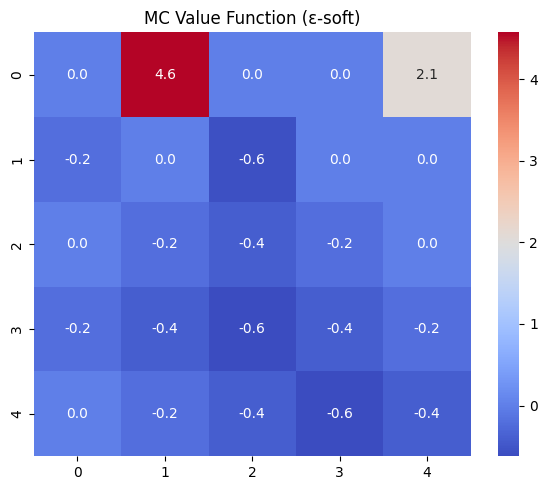

array([[ 0.        ,  4.57214818,  0.        ,  0.        ,  2.07650138],
       [-0.2       ,  0.        , -0.5705    ,  0.        ,  0.        ],
       [ 0.        , -0.2       , -0.40746463, -0.2       ,  0.        ],
       [-0.2       , -0.40620547, -0.61350078, -0.41421718, -0.2       ],
       [ 0.        , -0.2       , -0.41417493, -0.62170548, -0.41544812]])

In [27]:
# MC epsilon
def mc_control_epsilon_soft(num_episodes=10000, epsilon=0.1):
    Q = np.zeros((NUM_STATES, len(ACTIONS)))
    returns_count = np.zeros((NUM_STATES, len(ACTIONS)))
    
    # Initialize policy as uniform
    policy = np.ones((NUM_STATES, len(ACTIONS))) / len(ACTIONS)

    for _ in range(num_episodes):
        states, actions, rewards = generate_episode(policy=sample_from_policy(policy), exploring_starts=False)
        G, visited = 0, set()
        skip_propagation = False  # block backward flow only

        for t in reversed(range(len(states))):
            s, a, r = states[t], actions[t], rewards[t]
            coords = to_coords(s)

            G = GAMMA * G + r

            # ✅ Always update BLUE or GREEN (they should learn their own value)
            if coords in [BLUE, GREEN]:
                skip_propagation = True  # but prevent earlier states from absorbing G

            # ✅ Skip backpropagating the reward to states before BLUE/GREEN
            elif skip_propagation:
                continue

            if (s, a) not in visited:
                visited.add((s, a))
                returns_count[s, a] += 1
                Q[s, a] += (G - Q[s, a]) / returns_count[s, a]

                # ε-soft policy update
                best_action = np.argmax(Q[s])
                for a_i in range(len(ACTIONS)):
                    policy[s][a_i] = (
                        1 - epsilon + (epsilon / len(ACTIONS)) if a_i == best_action else epsilon / len(ACTIONS)
                    )




    return Q, policy


def sample_from_policy(policy_probs):
    def policy_fn(s):
        return np.random.choice(len(ACTIONS), p=policy_probs[s])
    return policy_fn


def generate_episode(policy=None, exploring_starts=False):
    states, actions, rewards = [], [], []
    
    # Start from random non-terminal state
    while True:
        s = random.randint(0, NUM_STATES - 1)
        if to_coords(s) not in TERMINAL_STATES:
            break

    # First action
    a = random.choice(range(len(ACTIONS))) if exploring_starts else (
        policy(s) if policy is not None else random.choice(range(len(ACTIONS)))
    )

    done, step_count = False, 0
    while not done and step_count < MAX_STEPS:
        states.append(s)
        actions.append(a)
        s_next, r, done = step(s, ACTIONS[a])
        rewards.append(r)

        if not done:
            a = policy(s_next) if policy is not None else random.choice(range(len(ACTIONS)))
        s = s_next
        step_count += 1

    return states, actions, rewards


Q_eps, pi_eps = mc_control_epsilon_soft(num_episodes=10000, epsilon=0.1)
V_eps = np.max(Q_eps, axis=1).reshape(GRID_SIZE, GRID_SIZE)

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(V_eps, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("MC Value Function (ε-soft)")
plt.tight_layout()
plt.show()


V_eps

### Off -Policy


Stable Off-Policy MC (Per-Decision IS) Policy Grid:
0 1 2 3 4
→ ↑ ← ← ↑
↓ ↑ ← ← ↓
X ← ← → X
↓ ↑ ← ↑ ↑
X ← ↑ ↑ ↑


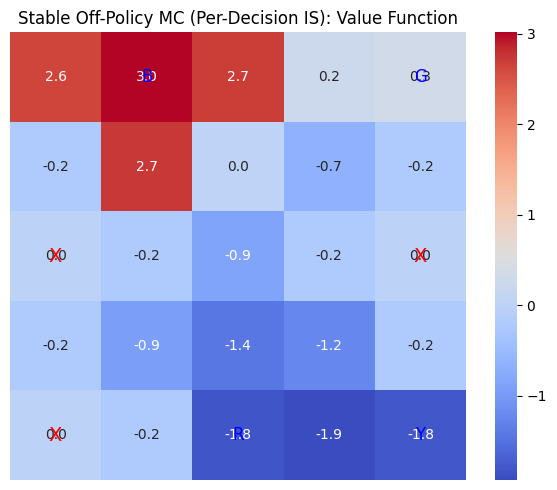

In [28]:
# ---------------- Environment Setup (Part 2) ----------------
GRID_SIZE = 5
NUM_STATES = GRID_SIZE * GRID_SIZE
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ACTION_NAMES = ['↑', '↓', '←', '→']
GAMMA = 0.95
MAX_STEPS = 50       # shorter episodes for stability
EPISODES = 10000     # fewer episodes to keep values bounded

BLUE = (0, 1)
GREEN = (0, 4)
RED = (4, 2)         # Correct RED for Part 2
YELLOW = (4, 4)
TERMINAL_STATES = [(2, 0), (2, 4), (4, 0)]

def to_index(i, j): return i * GRID_SIZE + j
def to_coords(s): return divmod(s, GRID_SIZE)

# Step function with BLUE/GREEN teleport logic and terminal states
def step(state, action):
    if to_coords(state) in TERMINAL_STATES:
        return state, 0, True

    i, j = to_coords(state)
    ni, nj = i + action[0], j + action[1]
    reward, done = 0, False

    if (i, j) == BLUE:
        return to_index(*RED), 5, False

    if (i, j) == GREEN:
        target = RED if np.random.rand() < 0.5 else YELLOW
        return to_index(*target), 2.5, False

    if not (0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE) and (i, j) not in [BLUE, GREEN]:
        return state, -0.5, False

    if 0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE:
        next_state = to_index(ni, nj)
        reward = -0.2
        done = (ni, nj) in TERMINAL_STATES
        return next_state, reward, done

    return state, reward, done

# ---------------- Stable Off-Policy MC with Per-Decision IS ----------------
def off_policy_mc_stable(episodes=EPISODES):
    """
    Off-Policy Monte Carlo Control using Per-Decision Importance Sampling (PDIS).
    - Behavior policy: uniform random (1/4 each).
    - Target policy: greedy w.r.t Q.
    - Uses decaying α to stabilize the highest values over time.
    """
    Q = { s: np.zeros(len(ACTIONS)) for s in range(NUM_STATES) }
    visit_counts = { (s,a): 0 for s in range(NUM_STATES) for a in range(len(ACTIONS)) }
    target_policy = { s: np.ones(len(ACTIONS)) / len(ACTIONS) for s in range(NUM_STATES) }

    for ep in range(episodes):
        episode = []
        valid_states = [to_index(i,j) for i in range(GRID_SIZE) for j in range(GRID_SIZE)
                        if (i,j) not in TERMINAL_STATES]
        state = random.choice(valid_states)
        action_idx = random.choice(range(len(ACTIONS)))
        steps = 0

        # Generate episode under uniform behavior policy
        while True:
            new_state, reward, done = step(state, ACTIONS[action_idx])
            episode.append((state, action_idx, reward))
            steps += 1
            if done or steps >= MAX_STEPS:
                break
            action_idx = random.choice(range(len(ACTIONS)))
            state = new_state

        # Backward pass: per-decision importance sampling
        G = 0.0
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = GAMMA * G + r

            # Greedy action check for target policy
            best_a = np.argmax(Q[s])
            rho = 1.0 if a == best_a else 0.0
            w_t = rho / 0.25  # behavior policy is uniform

            # Decaying learning rate: α = 1 / (1 + visits)
            visit_counts[(s,a)] += 1
            alpha = 1.0 / (1.0 + visit_counts[(s,a)])

            # Q update
            Q[s][a] += alpha * w_t * (G - Q[s][a])

            # Update greedy policy
            target_policy[s] = np.zeros(len(ACTIONS))
            target_policy[s][best_a] = 1.0

    return Q, target_policy

# ---------------- Helpers ----------------
def compute_state_values(Q_dict):
    values = np.zeros((GRID_SIZE, GRID_SIZE))
    for s, q_vals in Q_dict.items():
        i,j = to_coords(s)
        values[i,j] = np.max(q_vals)
    return values

def display_policy(policy_dict):
    grid = []
    for i in range(GRID_SIZE):
        row = []
        for j in range(GRID_SIZE):
            s = to_index(i,j)
            if (i,j) in TERMINAL_STATES:
                row.append("X")
            else:
                a = np.argmax(policy_dict[s])
                row.append(ACTION_NAMES[a])
        grid.append(row)
    return pd.DataFrame(grid)

def plot_value_function_no_arrows(values, title=""):
    plt.figure(figsize=(6, 5))
    sns.heatmap(values, annot=True, fmt=".1f", cmap="coolwarm", cbar=True)

    # Mark terminal and special squares
    for i,j in TERMINAL_STATES:
        plt.text(j+0.5, i+0.5, "X", ha='center', va='center', fontsize=14, color='red')
    for (i,j), label in {BLUE:'B', GREEN:'G', RED:'R', YELLOW:'Y'}.items():
        plt.text(j+0.5, i+0.5, label, ha='center', va='center', fontsize=12, color='blue')

    plt.title(title)
    plt.xlim(0, GRID_SIZE); plt.ylim(0, GRID_SIZE)
    plt.gca().invert_yaxis(); plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    plt.show()

# ---------------- Train and Visualize ----------------
Q_stable, policy_stable = off_policy_mc_stable(episodes=EPISODES)
V_stable = compute_state_values(Q_stable)

print("\nStable Off-Policy MC (Per-Decision IS) Policy Grid:")
print(display_policy(policy_stable).to_string(index=False))

plot_value_function_no_arrows(V_stable,
                              title="Stable Off-Policy MC (Per-Decision IS): Value Function")


#### Comparison among Monte Carlo method with (1) exploring starts and (2) without exploring starts but the ϵ-soft approac (3) Off-policy

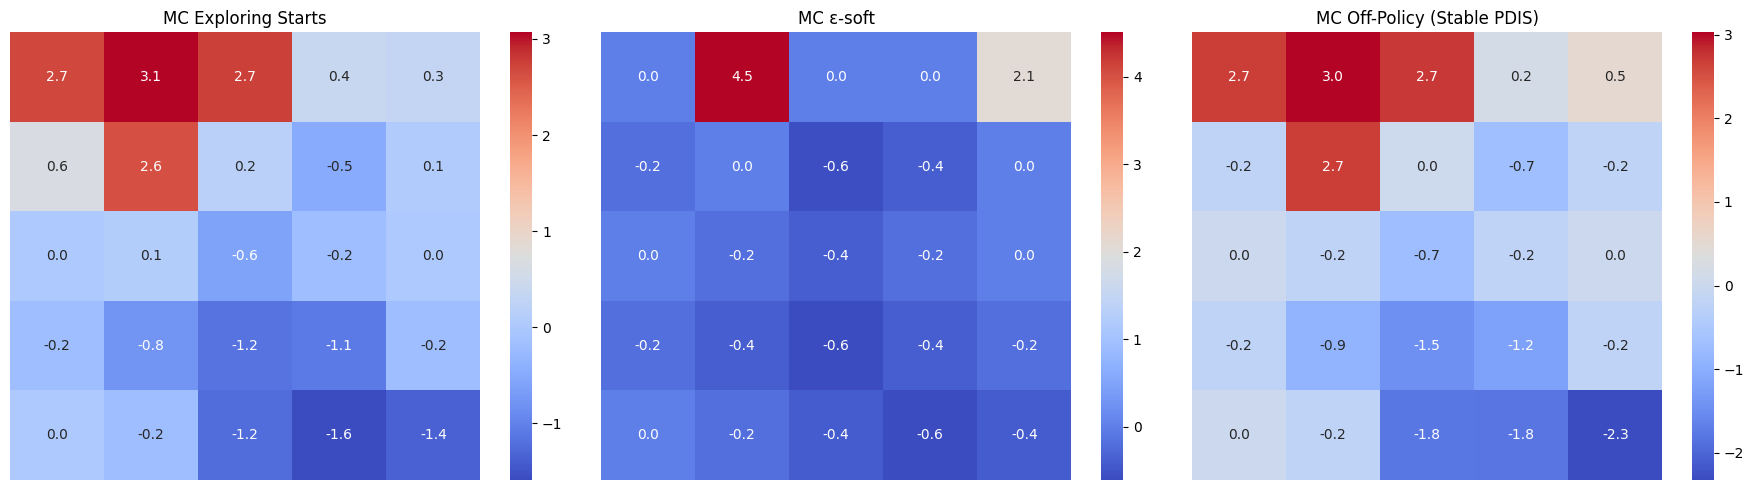

In [29]:
# ---------------- Train All Three MC Methods ----------------

EPISODES = 10000
MAX_STEPS = 50

# 1) Exploring Starts
Q_es, pi_es = mc_control_exploring_starts(num_episodes=EPISODES)
V_es = np.max(Q_es, axis=1).reshape(GRID_SIZE, GRID_SIZE)

# 2) ε-soft
Q_eps, pi_eps = mc_control_epsilon_soft(num_episodes=EPISODES, epsilon=0.1)
V_eps = np.max(Q_eps, axis=1).reshape(GRID_SIZE, GRID_SIZE)

# 3) Off-Policy (Stable Per-Decision IS)
Q_off, pi_off = off_policy_mc_stable(episodes=EPISODES)  # decaying α inside
V_off = compute_state_values(Q_off)

# ---------------- Side-by-Side Value Heatmaps (Values Only) ----------------
plt.figure(figsize=(18, 5))

for idx, (V, title) in enumerate(zip(
    [V_es, V_eps, V_off],
    ["MC Exploring Starts", "MC ε-soft", "MC Off-Policy (Stable PDIS)"]), 1):
    plt.subplot(1, 3, idx)
    sns.heatmap(V, annot=True, fmt=".1f", cmap="coolwarm", cbar=True)
    plt.title(title)
    plt.xlim(0, GRID_SIZE); plt.ylim(0, GRID_SIZE)
    plt.gca().invert_yaxis(); plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()


###### Comment: Here BLUE (0,1) is the most valuable state according to all methods but the scale varies due to variations in policy exploration and sampling variance.

###### Exploring Starts may underexplore extreme rewards but yields modest, steady estimates.

###### Long-term looping can cause ε-soft to underestimate some regions while inflating values close to BLUE.

###### Off-Policy PDIS is the most dependable for policy derivation since it achieves equilibrium with steady gradients and manageable peak values.